# Analytics & Visualization — FinTech 590

Derives key metrics from the pipeline outputs and produces charts for all top Uniswap V3 pools.

**Run order:** `defi_pipeline.ipynb` → `historical_data.ipynb` → `onchain_data.ipynb` → this notebook.

**Inputs:**
- `data/top_pools.parquet` — current pool snapshot (TVL, volume, verification)
- `data/pool_history.parquet` — daily TVL, APY, IL per pool (May 2021 → present)
- `data/pool_onchain.parquet` — live on-chain state (price, tick, liquidity)

**Sections:**
1. Load Data
2. Current Snapshot Metrics (TVL, volume, capital efficiency, fee revenue)
3. Historical Trends (TVL over time, APY comparison)
4. Risk Metrics (impermanent loss, APY volatility)
5. On-Chain State (live price vs historical, liquidity distribution)

## 0. Imports

In [16]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

POOLS_PARQUET   = pathlib.Path('data/top_pools.parquet')
HISTORY_PARQUET = pathlib.Path('data/pool_history.parquet')
ONCHAIN_PARQUET = pathlib.Path('data/pool_onchain.parquet')

## 1. Load Data

In [17]:
pools   = pd.read_parquet(POOLS_PARQUET)
history = pd.read_parquet(HISTORY_PARQUET)
onchain = pd.read_parquet(ONCHAIN_PARQUET)

# Friendly label for each pool
pools['label']   = pools['token0'] + '/' + pools['token1'] + ' ' + (pools['fee_tier']/1e4).map('{:.2f}%'.format) + ' (' + pools['chain'] + ')'
history['label'] = history['token0'] + '/' + history['token1'] + ' ' + (history['fee_tier']/1e4).map('{:.2f}%'.format)
onchain['label'] = onchain['token0'] + '/' + onchain['token1'] + ' ' + (onchain['fee']/1e4).map('{:.2f}%'.format) + ' (' + onchain['chain'] + ')'

print(f'Pools:   {len(pools)} rows')
print(f'History: {len(history):,} rows  |  {history["date"].min().date()} -> {history["date"].max().date()}')
print(f'Onchain: {len(onchain)} rows  |  fetched {onchain["fetched_at"].iloc[0]}')

Pools:   47 rows
History: 40,122 rows  |  2021-05-04 -> 2026-03-27
Onchain: 44 rows  |  fetched 2026-03-27


## 2. Current Snapshot Metrics

In [18]:
# Capital efficiency = volume / TVL  (higher means more trading activity per dollar locked)
# Fee revenue estimate = volume * fee_rate
pools['fee_rate']       = pools['fee_tier'] / 1e6
pools['cap_efficiency'] = pools['volume_usd'] / pools['tvl_usd']
pools['fee_revenue']    = pools['volume_usd'] * pools['fee_rate']

snapshot = pools[['label', 'chain', 'tvl_usd', 'volume_usd', 'cap_efficiency', 'fee_revenue']].copy()
snapshot = snapshot.sort_values('tvl_usd', ascending=False).reset_index(drop=True)

pd.options.display.float_format = '{:,.2f}'.format
print('Top pools by TVL:')
snapshot.head(10)

Top pools by TVL:


,label,chain,tvl_usd,volume_usd,cap_efficiency,fee_revenue
0,USDC/WETH 0.05% (Ethereum),Ethereum,"94,332,964.00","239,527,356.78",2.54,"119,763.68"
1,WETH/USDT 0.30% (Ethereum),Ethereum,"64,113,229.00","32,906,051.49",0.51,"98,718.15"
2,WBTC/WETH 0.05% (Arbitrum),Arbitrum,"48,017,394.00","44,795,288.98",0.93,"22,397.64"
3,WBTC/WETH 0.05% (Ethereum),Ethereum,"44,058,314.00","29,975,855.67",0.68,"14,987.93"
4,WBTC/WETH 0.30% (Ethereum),Ethereum,"42,024,669.00","696,288.30",0.02,"2,088.86"
5,WHITE/WETH 0.01% (Ethereum),Ethereum,"27,934,112.00",629.08,0.00,0.06
6,WBTC/CBBTC 0.01% (Ethereum),Ethereum,"27,295,581.00","9,611,741.25",0.35,961.17
7,USDC/USDT 0.01% (Ethereum),Ethereum,"26,930,451.00","27,451,173.86",1.02,"2,745.12"
8,WBTC/USDC 0.30% (Ethereum),Ethereum,"26,664,176.00","3,519,687.72",0.13,"10,559.06"
9,WBTC/USDT 0.30% (Ethereum),Ethereum,"25,621,363.00","2,888,057.67",0.11,"8,664.17"


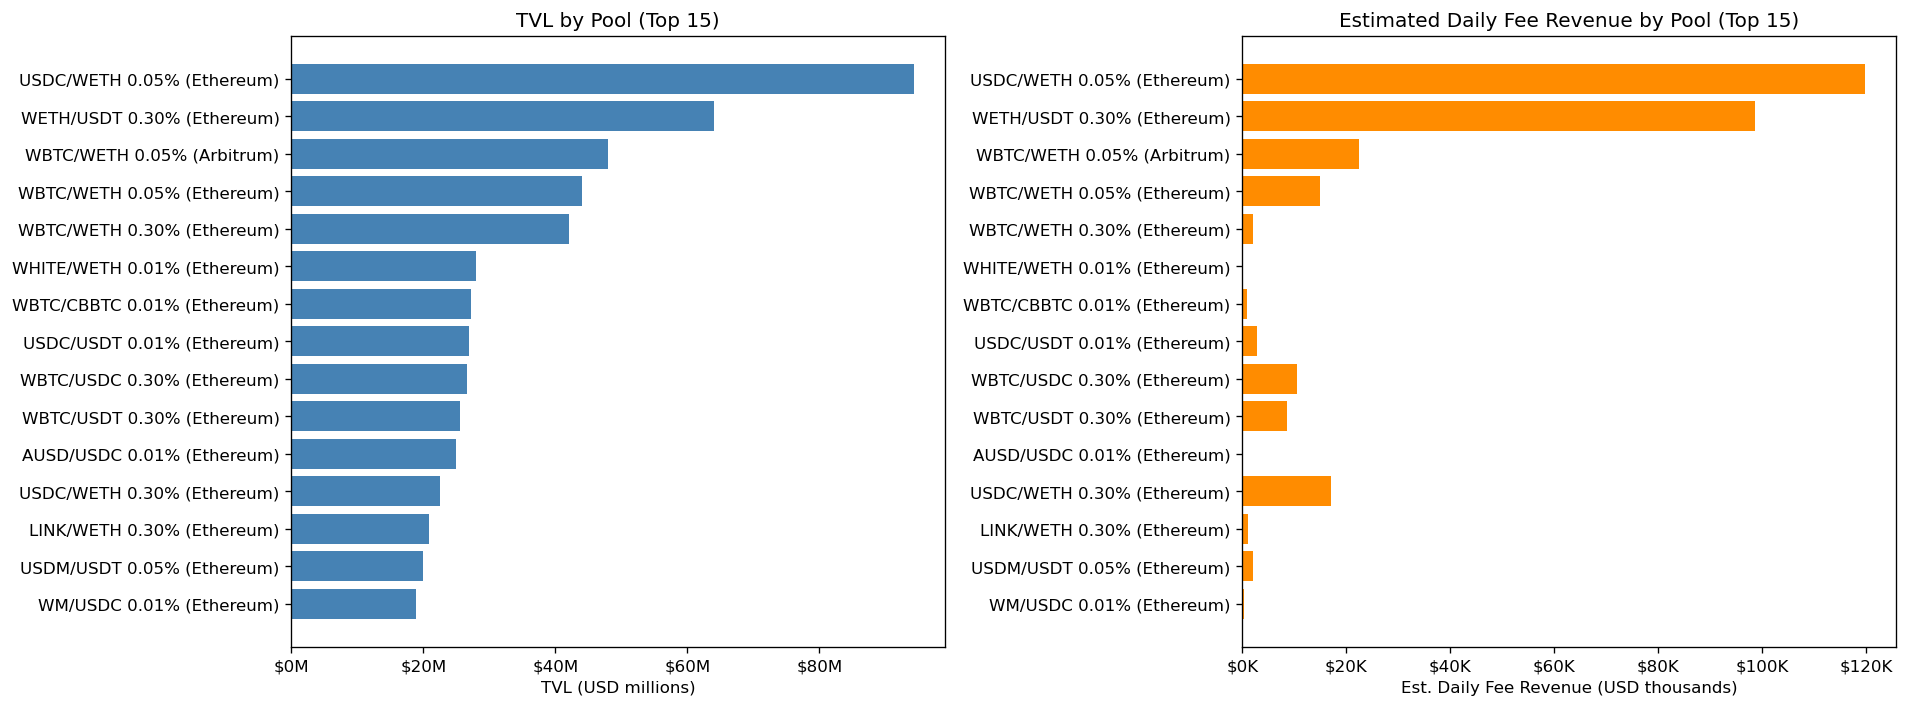

In [19]:
# Bar chart: TVL by pool (top 15)
top15 = snapshot.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TVL
axes[0].barh(top15['label'][::-1], top15['tvl_usd'][::-1] / 1e6, color='steelblue')
axes[0].set_xlabel('TVL (USD millions)')
axes[0].set_title('TVL by Pool (Top 15)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

# Daily fee revenue
axes[1].barh(top15['label'][::-1], top15['fee_revenue'][::-1] / 1e3, color='darkorange')
axes[1].set_xlabel('Est. Daily Fee Revenue (USD thousands)')
axes[1].set_title('Estimated Daily Fee Revenue by Pool (Top 15)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('data/tvl_fee_revenue.png', bbox_inches='tight')
plt.show()

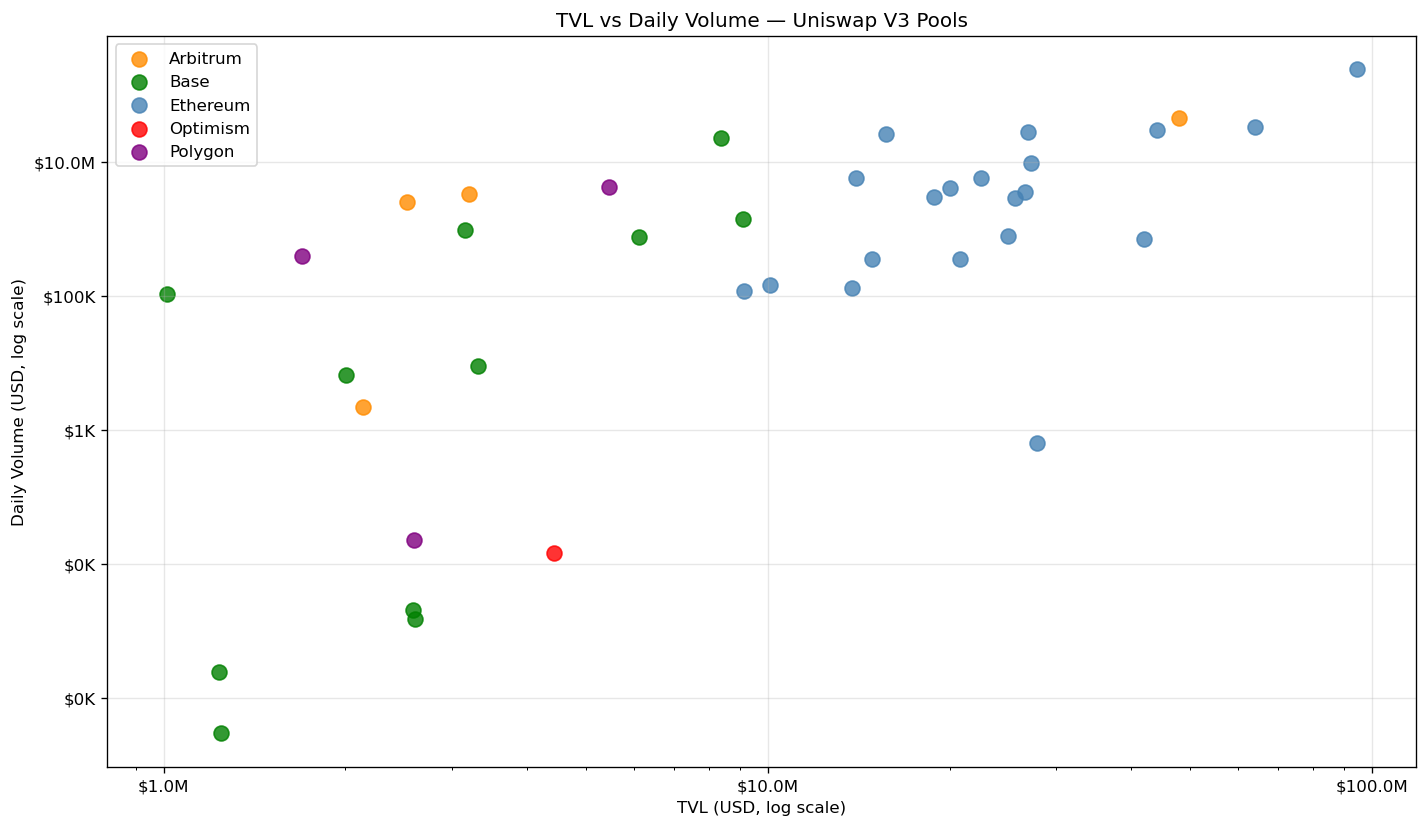

In [20]:
# Scatter: TVL vs volume (log scale) — reveals high-efficiency pools
fig, ax = plt.subplots(figsize=(12, 7))

chain_colors = {'Ethereum': 'steelblue', 'Arbitrum': 'darkorange', 'Base': 'green', 'Optimism': 'red', 'Polygon': 'purple'}
for chain, grp in pools.groupby('chain'):
    ax.scatter(grp['tvl_usd'], grp['volume_usd'], label=chain,
               color=chain_colors.get(chain, 'gray'), s=80, alpha=0.8)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('TVL (USD, log scale)')
ax.set_ylabel('Daily Volume (USD, log scale)')
ax.set_title('TVL vs Daily Volume — Uniswap V3 Pools')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/tvl_vs_volume.png', bbox_inches='tight')
plt.show()

Total TVL across all pools : $693.5M
Top 5 pools TVL            : $292.5M  (42.2% of total)


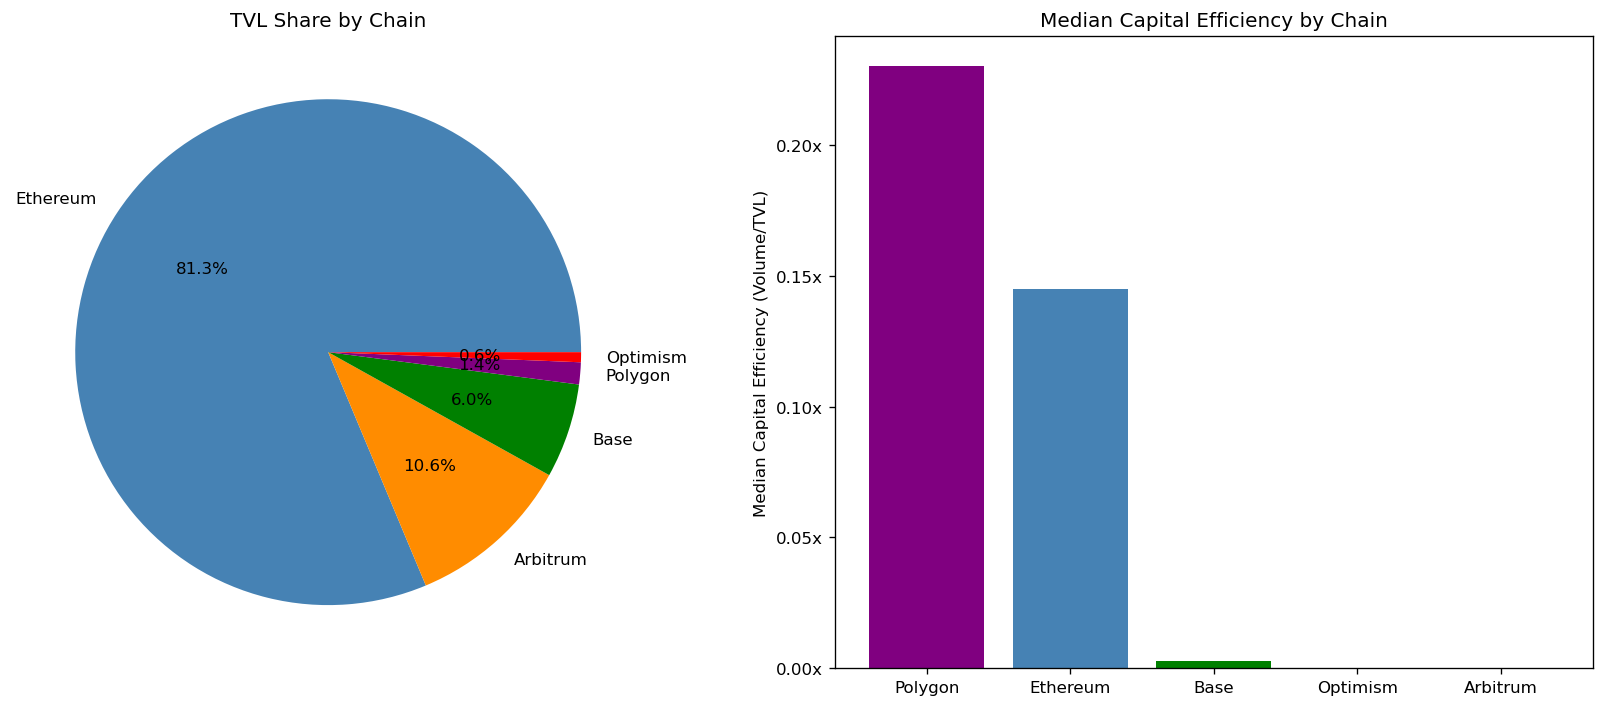

In [21]:
# TVL concentration: what % of total TVL is in the top 5 pools?
total_tvl = pools['tvl_usd'].sum()
top5_tvl  = pools.nlargest(5, 'tvl_usd')['tvl_usd'].sum()
print(f'Total TVL across all pools : ${total_tvl/1e6:,.1f}M')
print(f'Top 5 pools TVL            : ${top5_tvl/1e6:,.1f}M  ({top5_tvl/total_tvl*100:.1f}% of total)')

# Pie chart: TVL share by chain
tvl_by_chain = pools.groupby('chain')['tvl_usd'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(tvl_by_chain, labels=tvl_by_chain.index, autopct='%1.1f%%',
            colors=[chain_colors.get(c, 'gray') for c in tvl_by_chain.index])
axes[0].set_title('TVL Share by Chain')

# Capital efficiency by chain
eff_by_chain = pools.groupby('chain')['cap_efficiency'].median().sort_values(ascending=False)
axes[1].bar(eff_by_chain.index, eff_by_chain.values,
            color=[chain_colors.get(c, 'gray') for c in eff_by_chain.index])
axes[1].set_ylabel('Median Capital Efficiency (Volume/TVL)')
axes[1].set_title('Median Capital Efficiency by Chain')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}x'))

plt.tight_layout()
plt.savefig('data/tvl_concentration.png', bbox_inches='tight')
plt.show()

## 3. Historical Trends

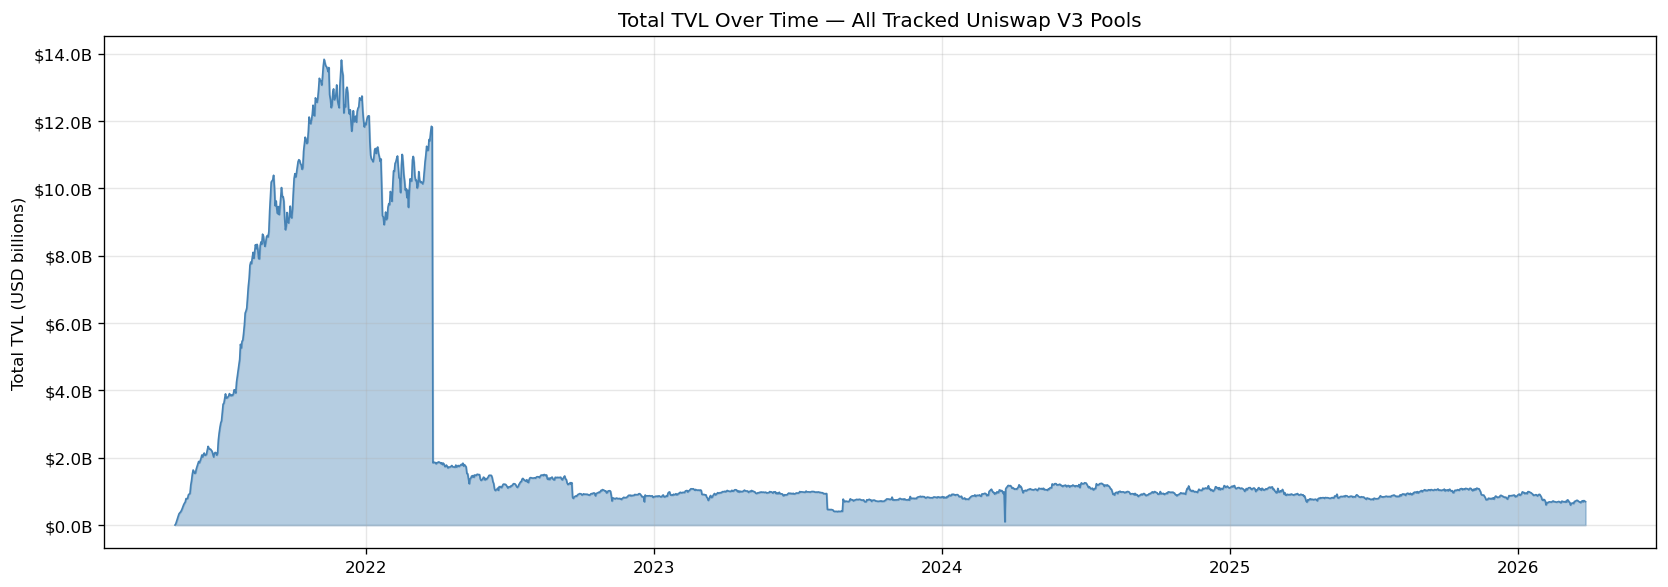

In [22]:
# Total TVL over time across all pools
daily_total = history.groupby('date')['tvl_usd'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_total['date'], daily_total['tvl_usd'] / 1e9, alpha=0.4, color='steelblue')
ax.plot(daily_total['date'], daily_total['tvl_usd'] / 1e9, color='steelblue', linewidth=1)
ax.set_ylabel('Total TVL (USD billions)')
ax.set_title('Total TVL Over Time — All Tracked Uniswap V3 Pools')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}B'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/tvl_over_time.png', bbox_inches='tight')
plt.show()

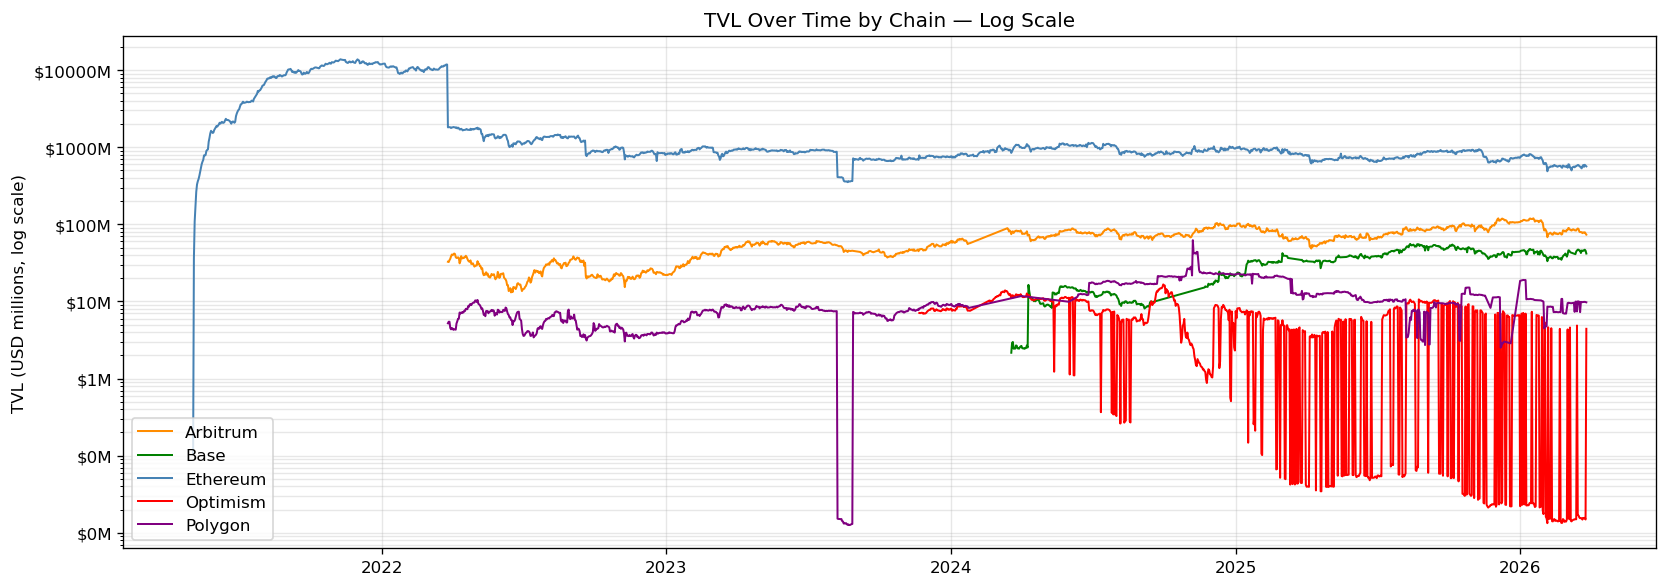

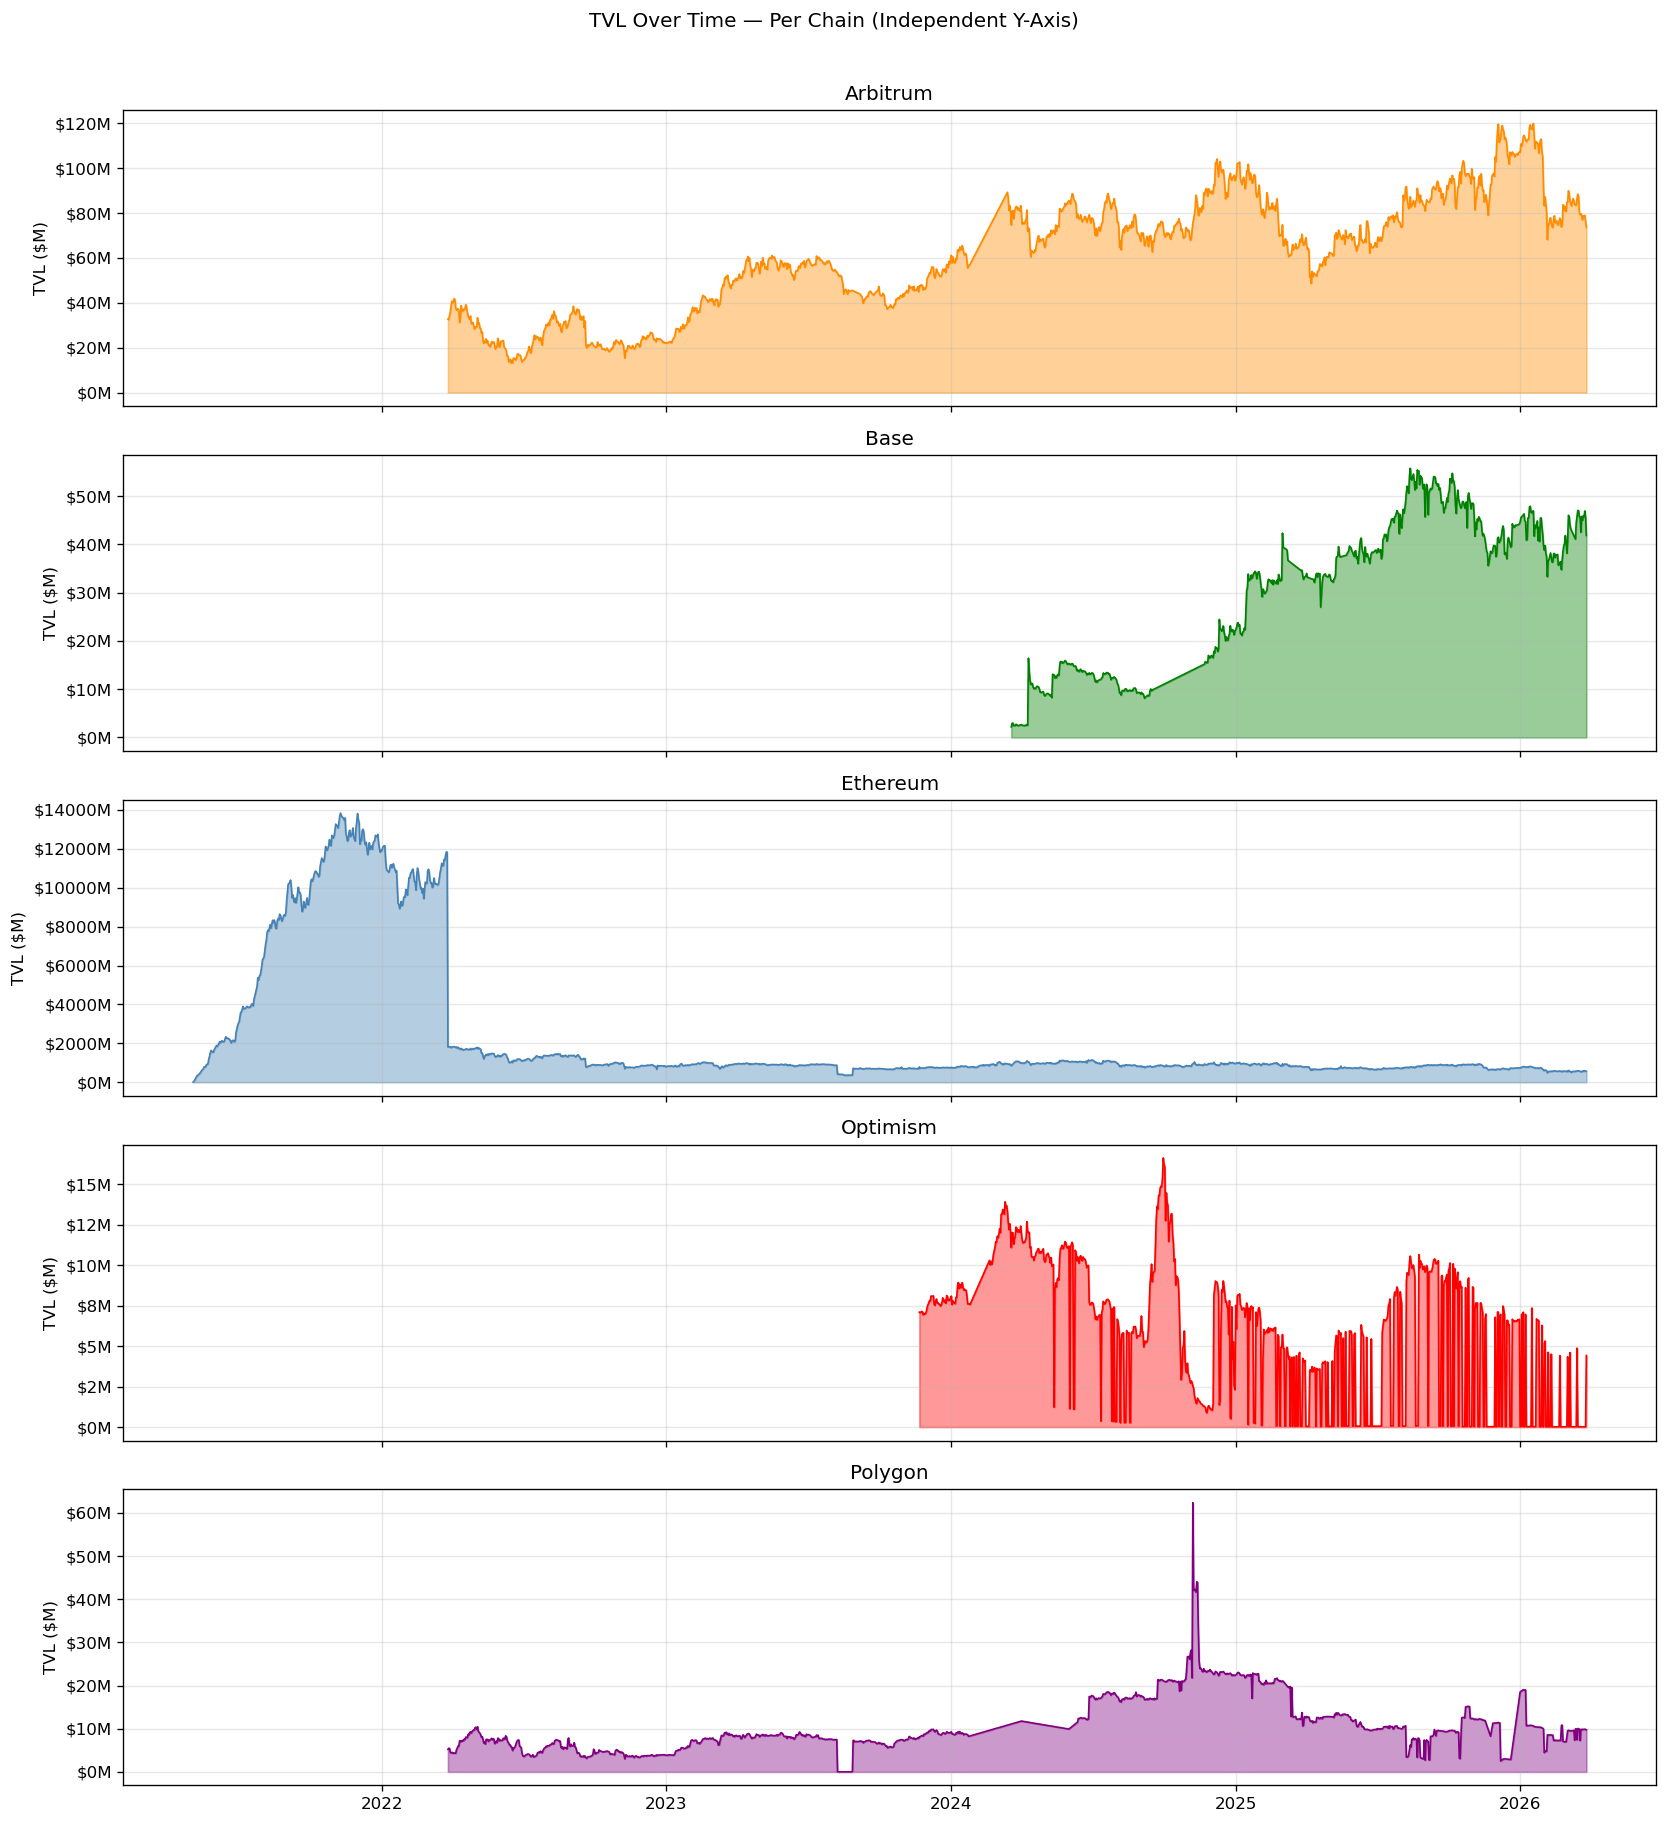

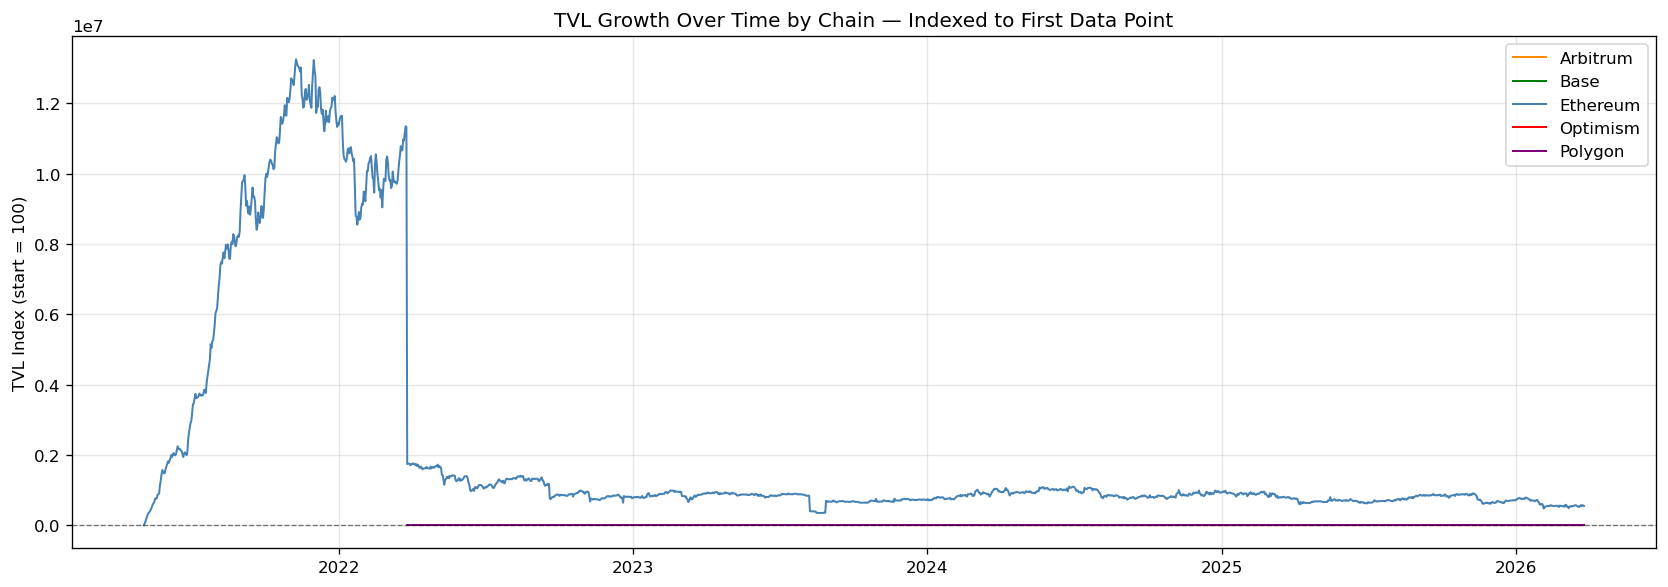

In [23]:
# TVL over time by chain — three views to handle Ethereum's dominance

daily_chain = history.groupby(['date', 'chain'])['tvl_usd'].sum().reset_index()
chains = daily_chain['chain'].unique()

# ── View 1: Log scale (all chains on one plot) ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for chain, grp in daily_chain.groupby('chain'):
    ax.plot(grp['date'], grp['tvl_usd'] / 1e6, label=chain,
            color=chain_colors.get(chain, 'gray'), linewidth=1.2)
ax.set_yscale('log')
ax.set_ylabel('TVL (USD millions, log scale)')
ax.set_title('TVL Over Time by Chain — Log Scale')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('data/tvl_by_chain_log.png', bbox_inches='tight')
plt.show()

# ── View 2: Separate subplots per chain (own y-axis each) ────────────────────
fig, axes = plt.subplots(len(chains), 1, figsize=(14, 3 * len(chains)), sharex=True)
for ax, chain in zip(axes, sorted(chains)):
    grp = daily_chain[daily_chain['chain'] == chain]
    ax.fill_between(grp['date'], grp['tvl_usd'] / 1e6, alpha=0.4,
                    color=chain_colors.get(chain, 'gray'))
    ax.plot(grp['date'], grp['tvl_usd'] / 1e6, color=chain_colors.get(chain, 'gray'), linewidth=1)
    ax.set_ylabel('TVL ($M)')
    ax.set_title(chain)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
    ax.grid(True, alpha=0.3)
plt.suptitle('TVL Over Time — Per Chain (Independent Y-Axis)', y=1.01)
plt.tight_layout()
plt.savefig('data/tvl_by_chain_subplots.png', bbox_inches='tight')
plt.show()

# ── View 3: Indexed to 100 at each chain's first data point ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for chain, grp in daily_chain.groupby('chain'):
    grp = grp.sort_values('date')
    first_val = grp['tvl_usd'].iloc[0]
    if first_val > 0:
        indexed = grp['tvl_usd'] / first_val * 100
        ax.plot(grp['date'], indexed, label=chain,
                color=chain_colors.get(chain, 'gray'), linewidth=1.2)
ax.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('TVL Index (start = 100)')
ax.set_title('TVL Growth Over Time by Chain — Indexed to First Data Point')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/tvl_by_chain_indexed.png', bbox_inches='tight')
plt.show()

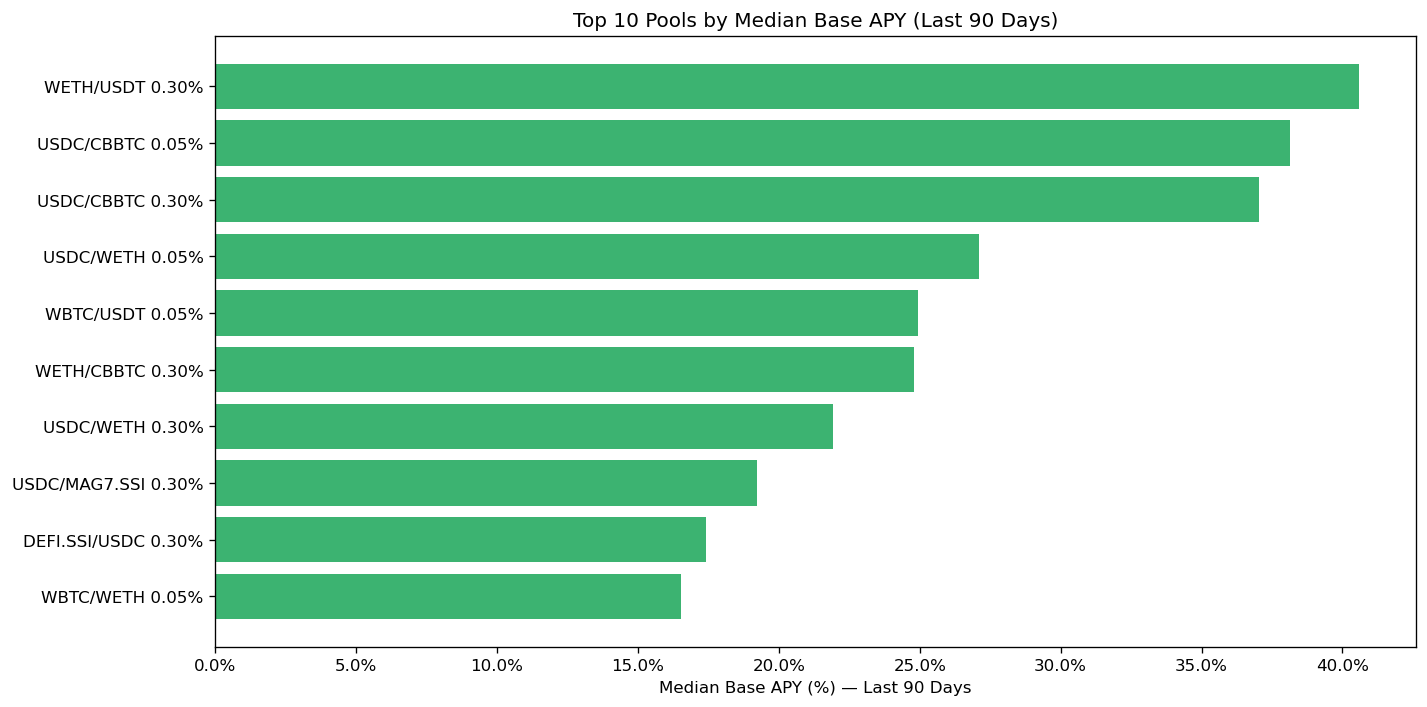

In [9]:
# APY comparison: last 90 days, top 10 pools by median APY
cutoff = history['date'].max() - pd.Timedelta(days=90)
recent = history[history['date'] >= cutoff].copy()

median_apy = (
    recent.groupby(['address', 'label'])['apy_base']
    .median()
    .reset_index()
    .sort_values('apy_base', ascending=False)
    .dropna()
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(median_apy['label'][::-1], median_apy['apy_base'][::-1], color='mediumseagreen')
ax.set_xlabel('Median Base APY (%) — Last 90 Days')
ax.set_title('Top 10 Pools by Median Base APY (Last 90 Days)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.savefig('data/apy_comparison.png', bbox_inches='tight')
plt.show()

## 4. Risk Metrics

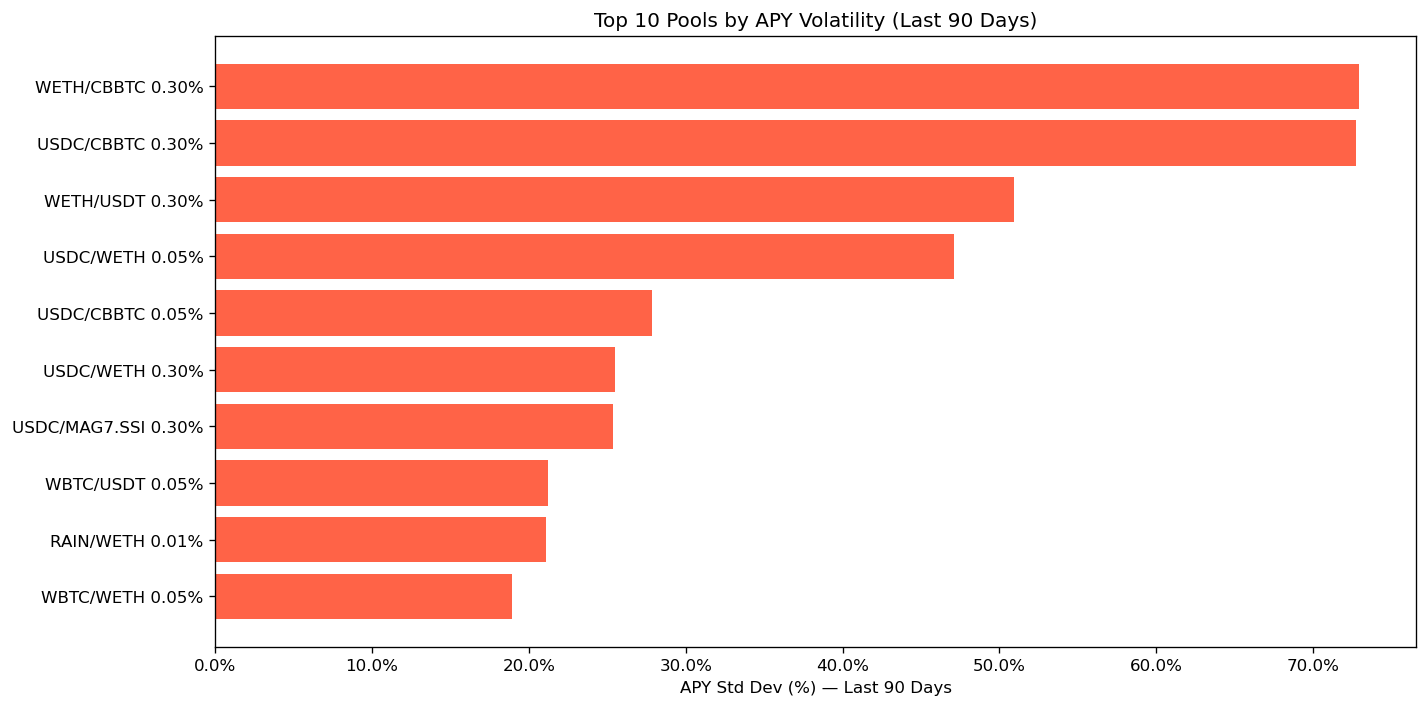

In [10]:
# APY volatility (std dev over last 90 days) — proxy for return stability
apy_vol = (
    recent.groupby(['address', 'label'])['apy_base']
    .std()
    .reset_index()
    .rename(columns={'apy_base': 'apy_std'})
    .dropna()
    .sort_values('apy_std', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(apy_vol['label'][::-1], apy_vol['apy_std'][::-1], color='tomato')
ax.set_xlabel('APY Std Dev (%) — Last 90 Days')
ax.set_title('Top 10 Pools by APY Volatility (Last 90 Days)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.savefig('data/apy_volatility.png', bbox_inches='tight')
plt.show()

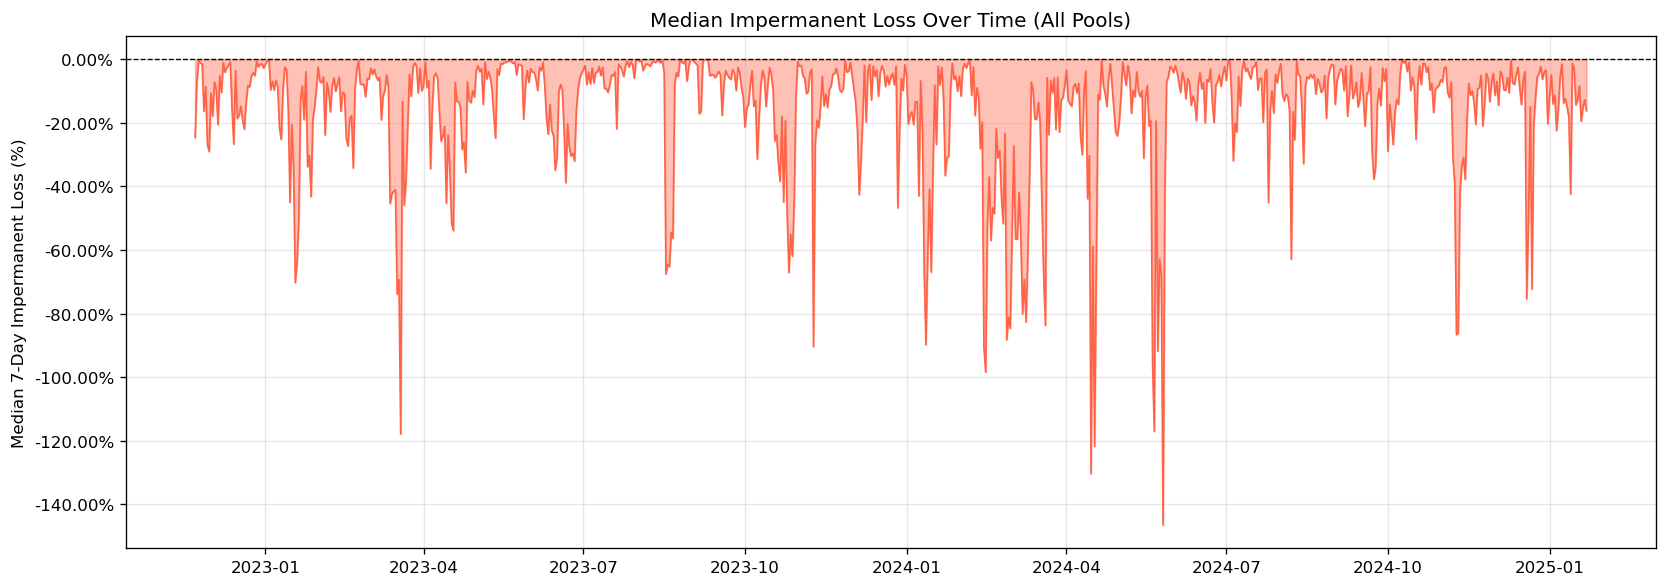

In [11]:
# Impermanent loss over time — median IL across all pools
il_data = history.dropna(subset=['il_7d'])
daily_il = il_data.groupby('date')['il_7d'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_il['date'], daily_il['il_7d'] * 100, alpha=0.4, color='tomato')
ax.plot(daily_il['date'], daily_il['il_7d'] * 100, color='tomato', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Median 7-Day Impermanent Loss (%)')
ax.set_title('Median Impermanent Loss Over Time (All Pools)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/il_over_time.png', bbox_inches='tight')
plt.show()

## 5. On-Chain State

In [12]:
# Live price vs historical average (last 30 days)
cutoff30 = history['date'].max() - pd.Timedelta(days=30)
hist30 = history[history['date'] >= cutoff30].copy()

# Join onchain price with historical APY for the same pool
onchain_display = onchain[['address', 'label', 'chain', 'token0', 'token1', 'price', 'tick', 'liquidity']].copy()
onchain_display['liquidity'] = onchain_display['liquidity'].astype(float)

print('Live On-Chain Pool State:')
onchain_display.sort_values('liquidity', ascending=False).reset_index(drop=True)

Live On-Chain Pool State:


,address,label,chain,token0,token1,price,tick,liquidity
0,0xC5c134A1f112efA96003f8559Dba6fAC0BA77692,WHITE/WETH 0.01% (Ethereum),Ethereum,WHITE,WETH,1.71,5355,"209,095,498,425,503,983,333,277,696.00"
1,0x4533bAD2dc588F0faDf8d2E72386d4cD6A19B519,WETH/PIKA 0.05% (Optimism),Optimism,WETH,PIKA,"6,146.01",87239,"112,367,865,164,591,525,454,151,680.00"
2,0x61928bf5f2895B682ecC9B13957AA5a5fE040cC0,WETH/PANANA 1.00% (Base),Base,WETH,PANANA,"1,206,270,531.62",209118,"10,866,425,812,775,334,242,680,832.00"
3,0xcFaf75a3d292C3535eA3acdb16Ed2EE58c2Bb091,WETH/BORED 1.00% (Base),Base,WETH,BORED,"4,617,867.63",153462,"1,394,285,617,348,319,163,449,344.00"
4,0xa6Cc3C2531FdaA6Ae1A3CA84c2855806728693e8,LINK/WETH 0.30% (Ethereum),Ethereum,LINK,WETH,0.00,-54492,"1,327,666,758,899,451,559,936,000.00"
5,0x7A415B19932c0105c82FDB6b720bb01B0CC2CAe3,WETH/WEETH 0.05% (Ethereum),Ethereum,WETH,WEETH,0.92,-869,"558,865,487,704,285,394,239,488.00"
6,0x7EB847a214192AAB8FA1b503f4d4C9Ddd2A08dB6,WETH/TICKER 1.00% (Base),Base,WETH,TICKER,"3,501,966.58",150695,"454,642,868,665,992,903,393,280.00"
7,0x1DFc1054E0e2A10E33C9ca21aaD5AA8A1cCe91e3,HEGIC/WETH 0.05% (Arbitrum),Arbitrum,HEGIC,WETH,0.00,-118752,"269,157,386,668,580,819,435,520.00"
8,0x1d42064Fc4Beb5F8aAF85F4617AE8b3b5B8Bd801,UNI/WETH 0.30% (Ethereum),Ethereum,UNI,WETH,0.00,-63731,"165,870,306,869,679,199,617,024.00"
9,0xd13040d4fe917EE704158CfCB3338dCd2838B245,RAIN/WETH 0.01% (Arbitrum),Arbitrum,RAIN,WETH,0.00,-123664,"45,641,369,964,391,107,133,440.00"


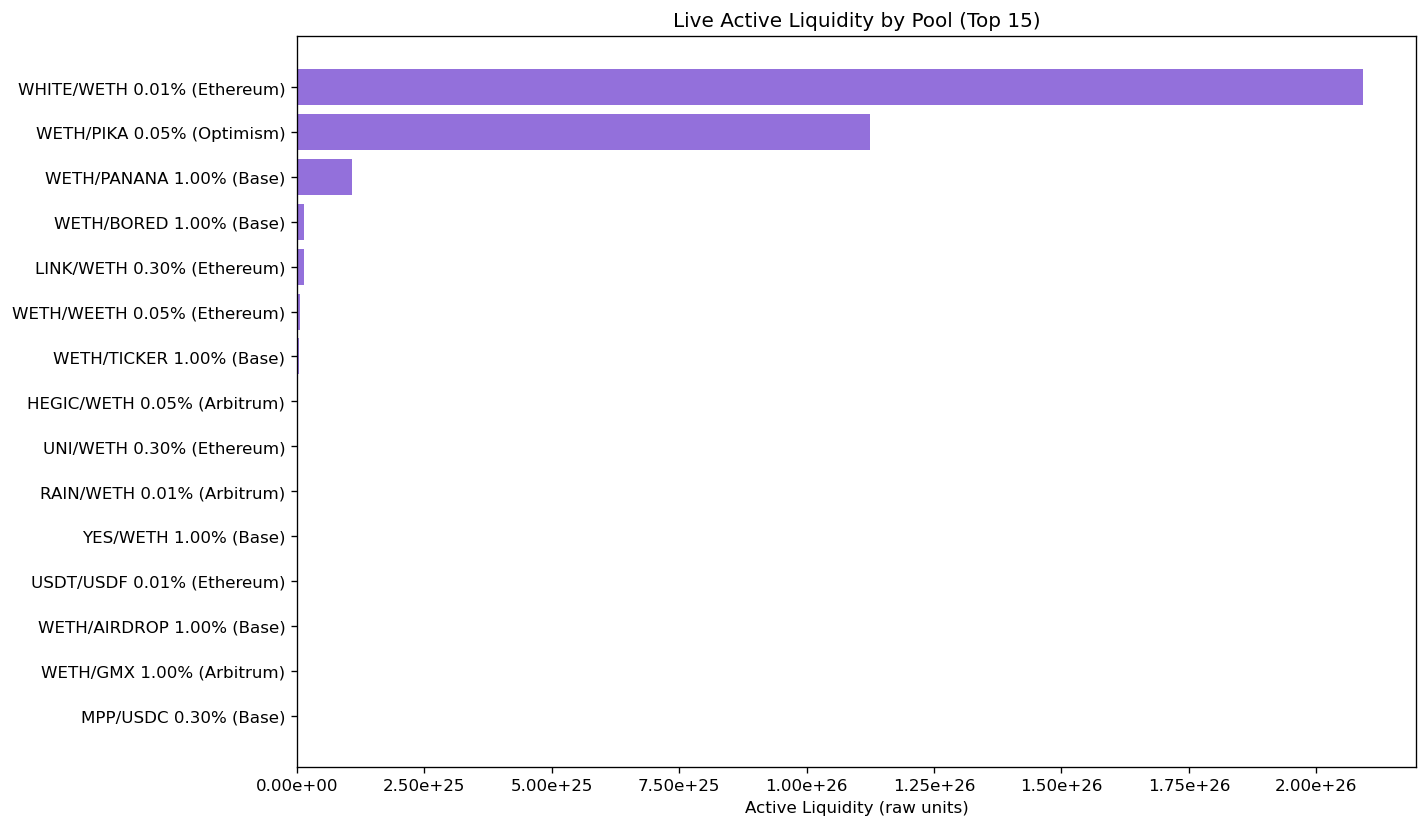

In [13]:
# Bar chart: live liquidity by pool (top 15)
top_liq = onchain_display.nlargest(15, 'liquidity')

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_liq['label'][::-1], top_liq['liquidity'][::-1], color='mediumpurple')
ax.set_xlabel('Active Liquidity (raw units)')
ax.set_title('Live Active Liquidity by Pool (Top 15)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2e}'))
plt.tight_layout()
plt.savefig('data/onchain_liquidity.png', bbox_inches='tight')
plt.show()

In [14]:
# Summary table: combine snapshot metrics with live state
summary = (
    pools[['address', 'label', 'chain', 'tvl_usd', 'volume_usd', 'cap_efficiency', 'fee_revenue']]
    .merge(
        onchain_display[['address', 'price', 'tick', 'liquidity']],
        on='address', how='left'
    )
    .merge(
        recent.groupby('address')['apy_base'].median().reset_index().rename(columns={'apy_base': 'median_apy_90d'}),
        on='address', how='left'
    )
    .sort_values('tvl_usd', ascending=False)
    .reset_index(drop=True)
)

print('Full Pool Summary:')
summary[['label', 'tvl_usd', 'volume_usd', 'cap_efficiency', 'fee_revenue', 'median_apy_90d', 'price']].head(15)

Full Pool Summary:


,label,tvl_usd,volume_usd,cap_efficiency,fee_revenue,median_apy_90d,price
0,USDC/WETH 0.05% (Ethereum),"94,332,964.00","239,527,356.78",2.54,"119,763.68",27.09,0.00
1,WETH/USDT 0.30% (Ethereum),"64,113,229.00","32,906,051.49",0.51,"98,718.15",40.58,"1,991.22"
2,WBTC/WETH 0.05% (Arbitrum),"48,017,394.00","44,795,288.98",0.93,"22,397.64",16.52,33.09
3,WBTC/WETH 0.05% (Ethereum),"44,058,314.00","29,975,855.67",0.68,"14,987.93",14.75,33.10
4,WBTC/WETH 0.30% (Ethereum),"42,024,669.00","696,288.30",0.02,"2,088.86",4.34,33.12
5,WHITE/WETH 0.01% (Ethereum),"27,934,112.00",629.08,0.00,0.06,0.00,1.71
6,WBTC/CBBTC 0.01% (Ethereum),"27,295,581.00","9,611,741.25",0.35,961.17,1.44,1.00
7,USDC/USDT 0.01% (Ethereum),"26,930,451.00","27,451,173.86",1.02,"2,745.12",2.19,1.00
8,WBTC/USDC 0.30% (Ethereum),"26,664,176.00","3,519,687.72",0.13,"10,559.06",14.04,"65,810.40"
9,WBTC/USDT 0.30% (Ethereum),"25,621,363.00","2,888,057.67",0.11,"8,664.17",14.41,"65,848.56"
